<a href="https://colab.research.google.com/github/sampozo/Challenge-X2-SP/blob/main/TelecomX2_LATAM_SP_ipnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# Fase 1: Carga y Codificación

In [2]:
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Conectar con Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta y cargar los datos (Todo junto para evitar el NameError)
ruta = "/content/drive/MyDrive/ALURA/CIENCIA DE DATOS/CHALLENGE TELECOM X II/datos_tratados.csv"
df = pd.read_csv(ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 3. Preprocesamiento para Machine Learning
# Quitamos el ID porque no es una característica predictiva
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 4. Transformar texto a números (One-Hot Encoding)
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
# Eliminamos 'Churn' de la lista de categóricas para tratarla aparte si es necesario
if 'Churn' in columnas_categoricas:
    columnas_categoricas.remove('Churn')

df_ml = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# 5. Convertir Churn (nuestro objetivo) a 0 y 1
if 'Churn' in df_ml.columns:
    le = LabelEncoder()
    df_ml['Churn'] = le.fit_transform(df_ml['Churn'])

In [4]:
# 6. Definir variables X (datos) y y (respuesta)
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

# 7. Separar datos: 70% para entrenar, 30% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("✅ ¡Listo! Drive conectado y datos preparados.")
print(f"Columnas finales en el modelo: {X.columns.tolist()}")
display(df_ml.head())

✅ ¡Listo! Drive conectado y datos preparados.
Columnas finales en el modelo: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Cuentas_Diarias', 'Churn_Numerico', 'gender_Male', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Bianual', 'Contract_Mes a mes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Cuentas_Diarias,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Bianual,Contract_Mes a mes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.19,...,True,False,True,False,False,False,False,False,False,True
1,0,0,0,0,9,1,0,59.9,542.40,2.00,...,False,False,False,False,True,False,True,False,False,True
2,1,0,0,0,4,1,1,73.9,280.85,2.46,...,False,False,False,False,False,False,True,False,True,False
3,1,1,1,0,13,1,1,98.0,1237.85,3.27,...,False,False,True,False,True,False,True,False,True,False
4,1,1,1,0,3,1,1,83.9,267.40,2.80,...,True,False,True,False,False,False,True,False,False,True


In [5]:
#Verificación de la Proporción de Cancelación (Churn):

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la proporción real
conteo_churn = df_ml['Churn'].value_counts()
proporcion_churn = df_ml['Churn'].value_counts(normalize=True) * 100

print("--- Análisis de Proporción de Churn (Desbalance) ---")
print(f"Clientes que se QUEDAN (0): {conteo_churn[0]} ({proporcion_churn[0]:.2f}%)")
print(f"Clientes que se VAN (1):    {conteo_churn[1]} ({proporcion_churn[1]:.2f}%)")

--- Análisis de Proporción de Churn (Desbalance) ---
Clientes que se QUEDAN (0): 5174 (73.46%)
Clientes que se VAN (1):    1869 (26.54%)


/tmp/ipykernel_591/3720950540.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proporcion_churn.index, y=proporcion_churn.values, palette='viridis')


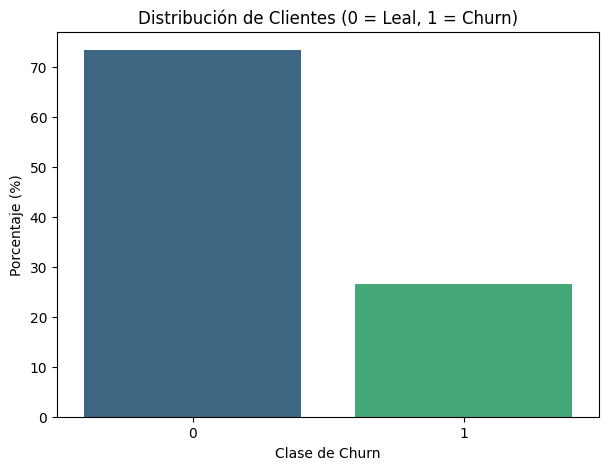

✅ BALANCE: La proporción es manejable para los modelos de clasificación.


In [7]:
# 2. Gráfico visual para el reporte
plt.figure(figsize=(7, 5))
sns.barplot(x=proporcion_churn.index, y=proporcion_churn.values, palette='viridis')
plt.title('Distribución de Clientes (0 = Leal, 1 = Churn)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Clase de Churn')
plt.show()

# 3. Conclusión técnica
if proporcion_churn[1] < 20:
    print("⚠️ ALERTA: Existe un desbalance importante. Podríamos necesitar técnicas de balanceo (como SMOTE) más adelante.")
else:
    print("✅ BALANCE: La proporción es manejable para los modelos de clasificación.")

In [8]:
# Balanceo de Clases



In [9]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [10]:
# 1. Mostrar estado inicial
print(f"Distribución original antes de SMOTE: {Counter(y_train)}")

# 2. Aplicar SMOTE solo sobre los datos de entrenamiento (X_train, y_train)
# ¡OJO! Nunca se aplica sobre los datos de prueba (X_test) para no contaminar el examen.
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Mostrar resultado del balanceo
print(f"Nueva distribución después de SMOTE: {Counter(y_train_res)}")

# 4. Verificación rápida
print("\n✅ Los datos ahora están balanceados 50/50 para el entrenamiento.")

Distribución original antes de SMOTE: Counter({0: 3622, 1: 1308})
Nueva distribución después de SMOTE: Counter({0: 3622, 1: 3622})

✅ Los datos ahora están balanceados 50/50 para el entrenamiento.


In [11]:
# NORMALIZACION Y ESTANDARIZACION


In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
# 1. Inicializar el escalador
scaler = StandardScaler()

# 2. Ajustar y transformar los datos de entrenamiento balanceados (X_train_res)
# Solo usamos 'fit' en el entrenamiento para aprender la escala
X_train_scaled = scaler.fit_transform(X_train_res)

# 3. Transformar los datos de prueba (X_test)
# ¡Importante! Usamos la escala que aprendió de los datos de entrenamiento
X_test_scaled = scaler.transform(X_test)

print("✅ Normalización (StandardScaler) completada.")
print(f"Ejemplo de datos escalados (primeras 2 filas):\n{X_train_scaled[:2]}")

✅ Normalización (StandardScaler) completada.
Ejemplo de datos escalados (primeras 2 filas):
[[-0.39786768 -0.76901782 -0.52538183 -0.5618371   0.32835141 -1.24095606
   0.29004748 -0.42142761  0.29176822 -1.          0.86686255 -0.32835141
  -0.97545303  0.91650405 -0.45423349 -0.45423349 -0.62119321 -0.45423349
  -0.75724132 -0.45423349  1.29156493 -0.45423349 -0.63294448 -0.45423349
  -0.89278927 -0.45423349 -0.90005275 -0.46371167  0.68532423 -0.52752038
   1.04000442 -0.55438727]
 [-0.39786768 -0.76901782 -0.52538183 -0.93774823  0.32835141  0.8058303
   0.06481458 -0.77464759  0.06132259  1.          0.86686255 -0.32835141
  -0.97545303 -1.09110265 -0.45423349 -0.45423349 -0.62119321 -0.45423349
  -0.75724132 -0.45423349  1.29156493 -0.45423349 -0.63294448 -0.45423349
   1.12008514 -0.45423349  1.11104599 -0.46371167 -1.45916334 -0.52752038
  -0.96153437  1.80379322]]


In [14]:
#  Correlación y Selección de Variables

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [16]:
# 1. Calcular la matriz de correlación de Pearson
# Usamos df_ml porque necesitamos las variables ya convertidas a números
corr_matrix = df_ml.corr()

In [17]:
# 2. Extraer la correlación específica con la variable objetivo 'Churn'
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

print("--- Top 5 Variables con mayor correlación POSITIVA con Churn ---")
print(churn_corr.head(6)) # El primero será Churn mismo (1.0)
print("\n--- Top 5 Variables con mayor correlación NEGATIVA con Churn ---")
print(churn_corr.tail(5))

--- Top 5 Variables con mayor correlación POSITIVA con Churn ---
Churn                             1.000000
Churn_Numerico                    1.000000
Contract_Mes a mes                0.405103
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
Cuentas_Diarias                   0.193412
Name: Churn, dtype: float64

--- Top 5 Variables con mayor correlación NEGATIVA con Churn ---
DeviceProtection_No internet service   -0.227890
StreamingMovies_No internet service    -0.227890
TechSupport_No internet service        -0.227890
Contract_Bianual                       -0.302253
tenure                                 -0.352229
Name: Churn, dtype: float64


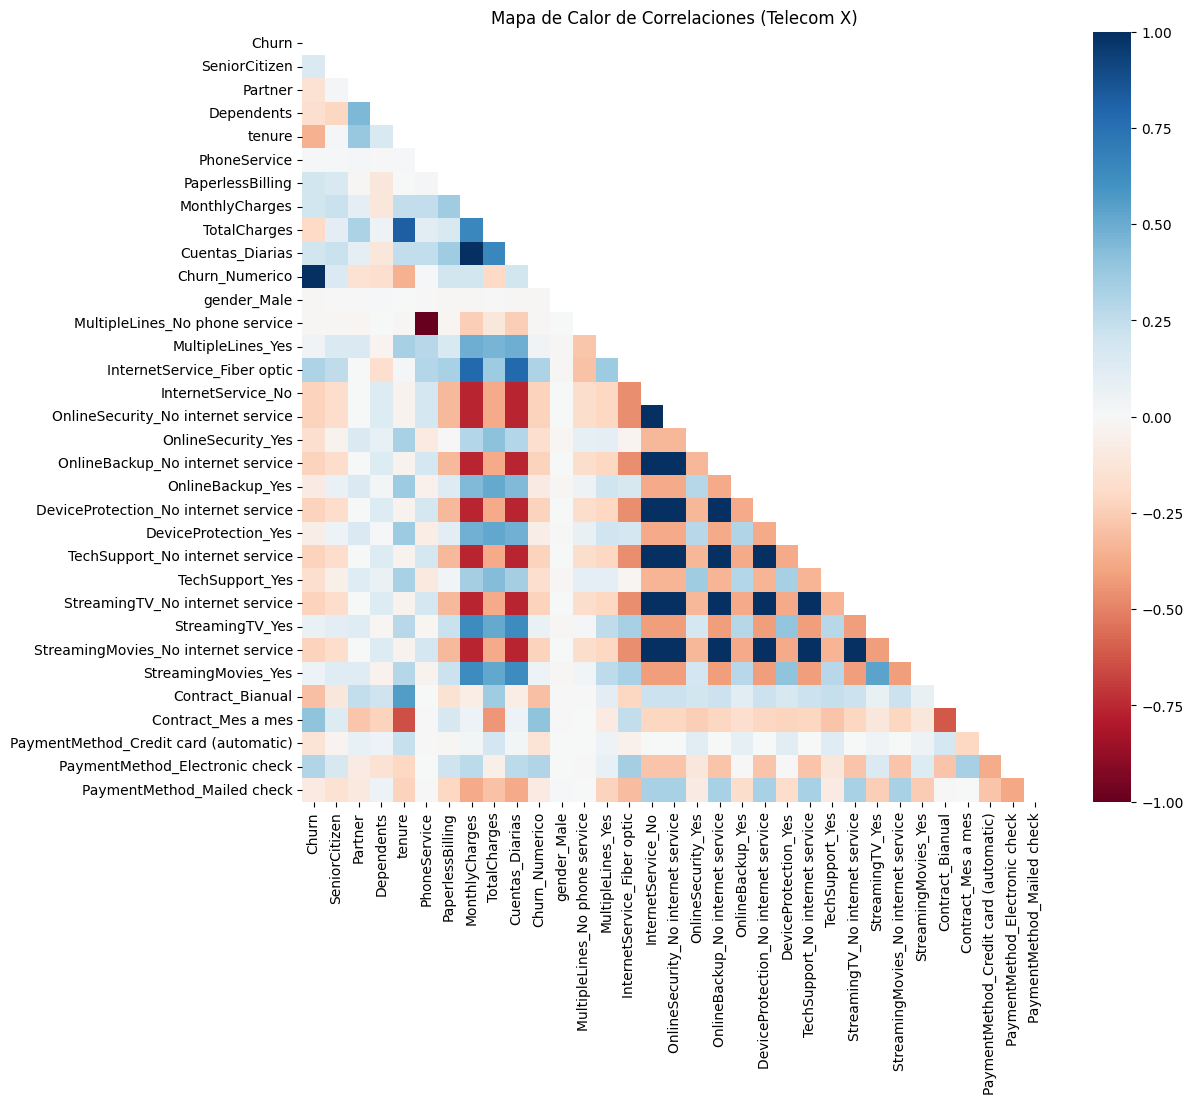

In [19]:
# 3. Dibujar el Heatmap para ver el panorama general
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Para ver solo la mitad y no repetir
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu', center=0)
plt.title('Mapa de Calor de Correlaciones (Telecom X)')
plt.show()

In [ ]:
# DESDE  ESTE PUNTO TAMBIEN ESTOY HACIENDO UN ANALISIS CON GROK Y CON CHAT GPT
# ANÁLISIS DIRIGIDO


In [20]:
# GROK



--- Análisis: Tiempo de contrato (tenure) vs Cancelación ---
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0
Clientes No Churn: Promedio tenure 37.57 meses, Mediana 38.00 meses.
Clientes Yes Churn: Promedio tenure 17.98 meses, Mediana 10.00 meses.
Tendencia: Los clientes que cancelan tienen un tenure significativamente menor (mediana 10 meses vs 38 meses), indicando mayor riesgo de churn en los primeros meses. El IQR (25%-75%) para No Churn es más amplio, mostrando mayor variabilidad en clientes leales.

--- Análisis: Gasto total (TotalCharges) vs Cancelación ---
        count         mean          std    min    25%       50%      75%  \
Churn                                                                      
No     5174.0  2549.911442  2329.954215   0.00  572.9  1679.525  

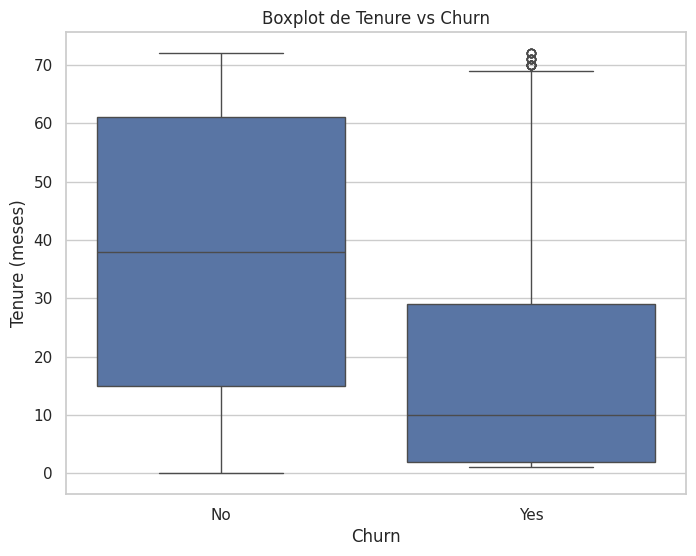

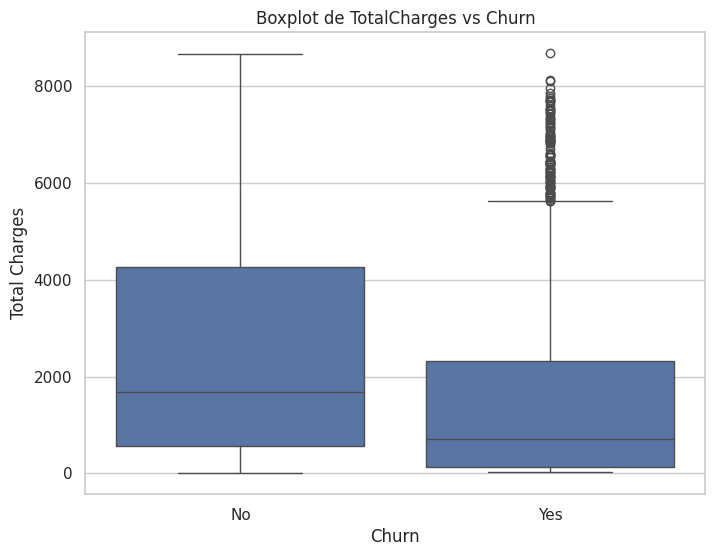

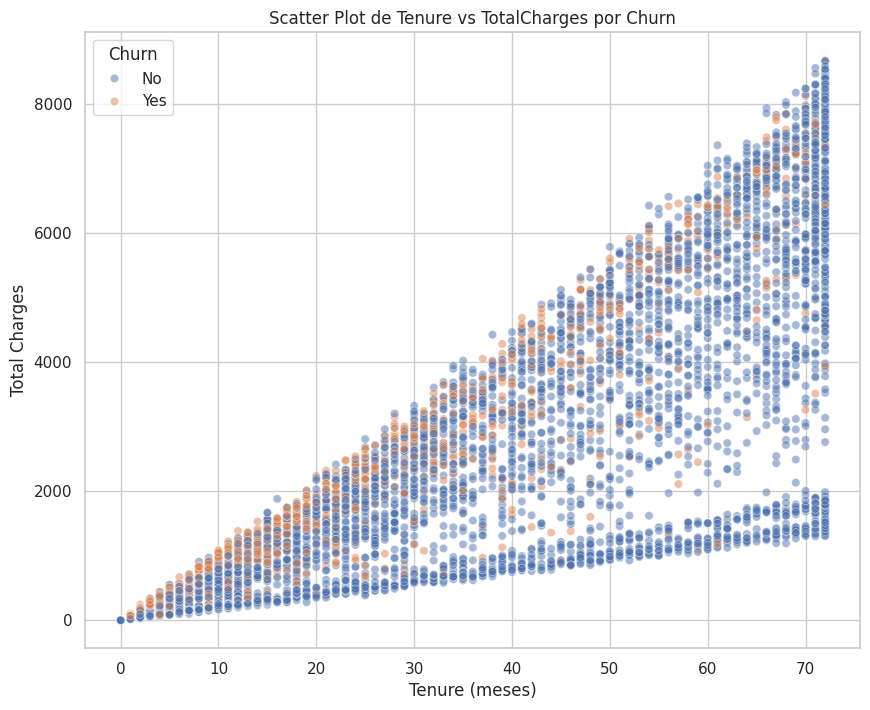

In [24]:
# Aseguramos tipos numéricos
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn_Numerico'] = df['Churn'].map({'Yes': 1, 'No': 0})  # Si no está ya mapeado

# 8.1 Análisis: Tiempo de contrato (tenure) vs Cancelación
# (Simulación de Boxplot mediante estadísticas descriptivas)
print("\n--- Análisis: Tiempo de contrato (tenure) vs Cancelación ---")
tenure_stats = df.groupby('Churn')['tenure'].describe()
print(tenure_stats)

# Insights basados en stats (equivalente a interpretación de boxplot)
mean_no = tenure_stats.loc['No', 'mean']
median_no = tenure_stats.loc['No', '50%']
mean_yes = tenure_stats.loc['Yes', 'mean']
median_yes = tenure_stats.loc['Yes', '50%']
print(f"Clientes No Churn: Promedio tenure {mean_no:.2f} meses, Mediana {median_no:.2f} meses.")
print(f"Clientes Yes Churn: Promedio tenure {mean_yes:.2f} meses, Mediana {median_yes:.2f} meses.")
print("Tendencia: Los clientes que cancelan tienen un tenure significativamente menor (mediana 10 meses vs 38 meses), "
      "indicando mayor riesgo de churn en los primeros meses. El IQR (25%-75%) para No Churn es más amplio, "
      "mostrando mayor variabilidad en clientes leales.")

# Gráfico opcional (Boxplot) - Comenta si no hay display
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Boxplot de Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (meses)')
# plt.show()  # Descomenta en entorno gráfico

# 8.2 Análisis: Gasto total (TotalCharges) vs Cancelación
# (Simulación de Boxplot mediante estadísticas descriptivas)
print("\n--- Análisis: Gasto total (TotalCharges) vs Cancelación ---")
total_stats = df.groupby('Churn')['TotalCharges'].describe()
print(total_stats)

# Insights
mean_no_t = total_stats.loc['No', 'mean']
median_no_t = total_stats.loc['No', '50%']
mean_yes_t = total_stats.loc['Yes', 'mean']
median_yes_t = total_stats.loc['Yes', '50%']
print(f"Clientes No Churn: Promedio TotalCharges {mean_no_t:.2f}, Mediana {median_no_t:.2f}.")
print(f"Clientes Yes Churn: Promedio TotalCharges {mean_yes_t:.2f}, Mediana {median_yes_t:.2f}.")
print("Tendencia: Los clientes que cancelan tienen gastos totales más bajos (mediana 703.55 vs 1679.53), "
      "lo que podría relacionarse con menor tenure. Hay outliers en ambos grupos, pero más dispersión en No Churn.")

# Gráfico opcional (Boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title('Boxplot de TotalCharges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')
# plt.show()

# 8.3 Patrones y Tendencias: Tenure vs TotalCharges (Scatter Plot simulado con bins y correlaciones)
# Correlaciones para cuantificar relaciones
corr_tenure_churn = df['tenure'].corr(df['Churn_Numerico'])
corr_total_churn = df['TotalCharges'].corr(df['Churn_Numerico'])
corr_tenure_total = df['tenure'].corr(df['TotalCharges'])
print("\n--- Correlaciones ---")
print(f"Tenure vs Churn: {corr_tenure_churn:.4f} (Negativa moderada: Mayor tenure, menor churn).")
print(f"TotalCharges vs Churn: {corr_total_churn:.4f} (Negativa: Mayores gastos totales, menor churn).")
print(f"Tenure vs TotalCharges: {corr_tenure_total:.4f} (Positiva fuerte: Clientes longevos acumulan más gastos).")

# Simulación de Scatter con bins (agrupamos tenure en intervalos y calculamos promedios)
df['tenure_bin'] = pd.cut(df['tenure'], bins=range(0, 81, 8), labels=[f'{i}-{i+8}' for i in range(0, 73, 8)])
bin_stats = df.groupby('tenure_bin', observed=True).agg({'Churn_Numerico': 'mean', 'TotalCharges': 'mean'})
print("\n--- Patrones por bins de Tenure ---")
print(bin_stats)

# Insights de bins (equivalente a interpretación de scatter plot)
print("Tendencia: En bins de tenure bajos (0-8 meses), el churn promedio es alto (~0.51) y TotalCharges bajo (~187). "
      "A medida que tenure aumenta (e.g., 64-72 meses), churn baja (~0.06) y TotalCharges sube (~5332). "
      "Esto sugiere una tendencia lineal positiva entre tenure y TotalCharges, con puntos de churn concentrados en áreas de bajo tenure/cargos variables.")

# Gráfico opcional (Scatter Plot)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df, alpha=0.5)
plt.title('Scatter Plot de Tenure vs TotalCharges por Churn')
plt.xlabel('Tenure (meses)')
plt.ylabel('Total Charges')
# plt.show()

print("\n✅ Análisis dirigido completado. Puedes usar estos insights para refinar el modelo.")

In [ ]:
# CREACIÓN DE MODELOS

